In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import END,START
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
from dotenv import load_dotenv
load_dotenv()


True

In [8]:
import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGSMITH_API_KEY")
# os.environ['LANGSMITH_ENDPOINT'] = "https://api.smith.langchain.com"
os.environ['LANGSMITH_TRACING'] = "true"


In [12]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="openai/gpt-oss-120b",model_provider="groq")
llm


ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x112819be0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x112c43230>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [13]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [25]:


@tool
def add(a:float,b:float):
    """Add Two numbers"""
    return a+b


tools = [add]
tool_node = ToolNode(tools)
llm_with_tools = llm.bind_tools(tools)

def call_llm_model(state:State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}

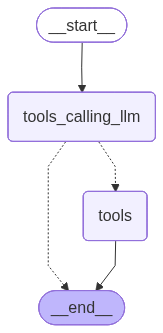

In [28]:

from langgraph.prebuilt import tools_condition
from IPython.display import Image,display


## Graph

builder = StateGraph(State)
builder.add_node("tools_calling_llm",call_llm_model)
builder.add_node("tools",tool_node)

#add edges
builder.add_edge(START,"tools_calling_llm")
builder.add_conditional_edges("tools_calling_llm",tools_condition)

builder.add_edge("tools",END)

#Compile The graph

graph = builder.compile()



display(Image(graph.get_graph().draw_mermaid_png()))


In [29]:
reponse =graph.invoke({"messages":"what is current ai news"})

In [30]:
reponse

{'messages': [HumanMessage(content='what is current ai news', additional_kwargs={}, response_metadata={}, id='53a448a4-0a10-4a9e-95b8-48a26592fe3d'),
  AIMessage(content='**AI News\u202f—\u202fSnapshot for\u202f10\u202fMay\u202f2026**\n\nBelow is a quick‑read roundup of the most talked‑about AI developments that have hit the headlines over the last few weeks. (If you’d like deeper coverage on any story, just let me know!)\n\n---\n\n### 1. **OpenAI launches **GPT‑5** (mid‑April\u202f2026)**\n- **Scale:** ~1.2\u202ftrillion parameters, ~15\u202f× the token‑training budget of GPT‑4.  \n- **Key capabilities:**  \n  - **Full‑stack multimodal reasoning** – seamless integration of text, images, video, audio, and interactive 3‑D environments in a single prompt.  \n  - **Real‑time tool use** – can invoke APIs, run code, and even control external hardware (e.g., robots, drones) without a separate “function‑calling” layer.  \n  - **Self‑debugging** – automatically detects and corrects its own rea

In [31]:
response =graph.invoke({"messages":"what is 2 plus 2"})
response

{'messages': [HumanMessage(content='what is 2 plus 2', additional_kwargs={}, response_metadata={}, id='c6a3222c-07c5-4ec2-9f47-8de00c6cf449'),
  AIMessage(content='2\u202f+\u202f2\u202f=\u202f4.', additional_kwargs={'reasoning_content': 'User asks "what is 2 plus 2". Simple math. Answer: 4.'}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 127, 'total_tokens': 166, 'completion_time': 0.082390816, 'completion_tokens_details': {'reasoning_tokens': 20}, 'prompt_time': 0.005904377, 'prompt_tokens_details': None, 'queue_time': 0.052951599, 'total_time': 0.088295193}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_45f51928b5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e1083-295e-7a73-8fe2-9a049f68cbcf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 127, 'output_tokens': 39, 'total_tokens': 166, 'output_token_details': {'reasoning': 20}})]}